In [1]:
precip = ds["precip"]

NameError: name 'ds' is not defined

/jobfs/171422796.gadi-pbs/ipykernel_3405377/1527171333.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


Input period:
1900-01-16T00:00:00.000000000
2024-12-16T00:00:00.000000000
<xarray.DataArray 'precip' (time: 504, lat: 691, lon: 886)> Size: 1GB
dask.array<getitem, shape=(504, 691, 886), dtype=float32, chunksize=(12, 691, 886), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1940-05-16 ... 2023-10-16
  * lat      (lat) float32 3kB -44.5 -44.45 -44.4 -44.35 ... -10.1 -10.05 -10.0
  * lon      (lon) float32 4kB 112.0 112.1 112.1 112.2 ... 156.1 156.2 156.2
Attributes:
    cell_methods:           time: sum time: sum (interval : 1 day)
    units:                  mm
    long_name:              Daily precipitation
    standard_name:          lwe_thickness_of_precipitation_amount
    frequency:              monthly
    start_offset:           -24
    grid_mapping:           crs
    coverage_content_type:  physicalMeasurement
    valid_range:            [     0. 100000.]
<xarray.DataArray 'cool_p25' (lat: 691, lon: 886)> Size: 5MB
dask.array<getitem, shape=(691, 8

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


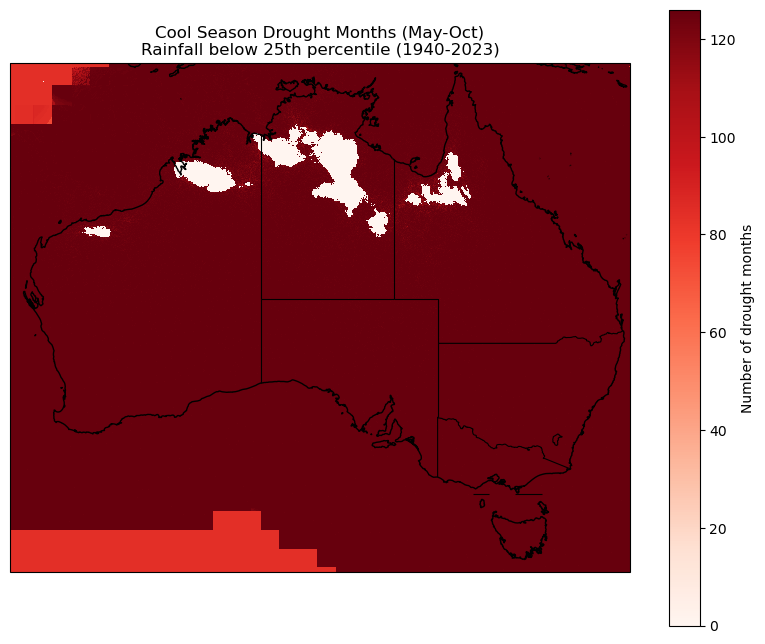

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# 1. Open AGCD monthly precipitation
# --------------------------------------------------

ds = xr.open_mfdataset(
    "/g/data/zv2/agcd/v2-0-3/precip/total/r005/01month/agcd_v2_precip_total_r005_monthly_*.nc",
    combine="by_coords",
    chunks={"time": 120}
)

precip = ds["precip"]

print("Input period:")
print(precip.time.min().values)
print(precip.time.max().values)

# --------------------------------------------------
# 2. Select 1940-2023
# --------------------------------------------------

precip = precip.sel(
    time=slice("1940-01-01", "2023-12-31")
)

# --------------------------------------------------
# 3. Select cool season months (May-Oct)
# --------------------------------------------------

cool = precip.sel(
    time=precip.time.dt.month.isin([5, 6, 7, 8, 9, 10])
)

print(cool)

# Expected:
# time = 504
# lat = 691
# lon = 886

# --------------------------------------------------
# 4. Calculate 25th percentile threshold
# --------------------------------------------------

cool_p25 = cool.quantile(
    0.25,
    dim="time"
)

cool_p25 = cool_p25.rename("cool_p25")

print(cool_p25)

# Expected:
# (lat: 691, lon: 886)

# --------------------------------------------------
# 5. Identify drought months
# rainfall < 25th percentile
# --------------------------------------------------

drought = cool < cool_p25

print(drought)

# Boolean array:
# True  = drought month
# False = non-drought month

# --------------------------------------------------
# 6. Count drought months
# --------------------------------------------------

drought_count = drought.sum(dim="time")

drought_count = drought_count.rename(
    "cool_drought_month_count"
)

print(drought_count)

# Expected:
# (lat: 691, lon: 886)

# --------------------------------------------------
# 7. Plot map
# --------------------------------------------------

fig = plt.figure(figsize=(10, 8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

drought_count.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    cbar_kwargs={
        "label": "Number of drought months"
    }
)

ax.coastlines("10m")

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

ax.add_feature(
    states,
    edgecolor="black",
    linewidth=0.8
)

ax.set_extent(
    [112, 154, -44.5, -10],
    crs=ccrs.PlateCarree()
)

plt.title(
    "Cool Season Drought Months (May-Oct)\n"
    "Rainfall below 25th percentile (1940-2023)"
)

plt.show()